# Smart Fertilizer Recommendation System

This notebook builds a machine learning model that recommends fertilizers based on soil conditions, crop type, and environmental parameters.

The system analyzes:

- Soil nutrients (Nitrogen, Phosphorus, Potassium)
- Soil pH
- Soil moisture
- Weather conditions
- Crop type
- Crop growth stage

The goal is to generate fertilizer recommendations using a Random Forest model.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/RKdemy/fertilizer_recommendation.csv")

In [ ]:
df.head()

,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Nitrogen_Level,Phosphorus_Level,Potassium_Level,Temperature,Humidity,Rainfall,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Previous_Crop,Region,Fertilizer_Used_Last_Season,Yield_Last_Season,Recommended_Fertilizer
0,Clay,6.07,34.98,0.32,1.87,61,44,84,19.84,83.31,1693.22,Cotton,Harvest,Kharif,Canal,Wheat,South,297.15,1.19,MOP
1,Silt,6.39,47.34,0.28,0.21,59,56,18,24.40,46.27,1030.21,Maize,Vegetative,Kharif,Sprinkler,Potato,Central,77.17,4.40,Urea
2,Sandy,7.92,38.13,0.99,1.88,43,21,119,24.82,71.86,1166.16,Cotton,Flowering,Kharif,Rainfed,Tomato,South,128.93,7.21,Urea
3,Clay,5.86,14.17,1.46,0.36,88,46,34,27.87,53.23,2881.83,Wheat,Flowering,Zaid,Sprinkler,Potato,West,233.96,1.85,MOP
4,Clay,7.98,19.28,0.85,2.16,104,53,98,24.17,51.87,714.84,Potato,Sowing,Kharif,Rainfed,Maize,East,214.39,7.36,Zinc Sulphate


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Soil_Type                    10000 non-null  object 
 1   Soil_pH                      10000 non-null  float64
 2   Soil_Moisture                10000 non-null  float64
 3   Organic_Carbon               10000 non-null  float64
 4   Electrical_Conductivity      10000 non-null  float64
 5   Nitrogen_Level               10000 non-null  int64  
 6   Phosphorus_Level             10000 non-null  int64  
 7   Potassium_Level              10000 non-null  int64  
 8   Temperature                  10000 non-null  float64
 9   Humidity                     10000 non-null  float64
 10  Rainfall                     10000 non-null  float64
 11  Crop_Type                    10000 non-null  object 
 12  Crop_Growth_Stage            10000 non-null  object 
 13  Season           

### Observations

- Dataset contains 10,000 samples.
- No missing values were detected.
- Some columns are categorical and require encoding.

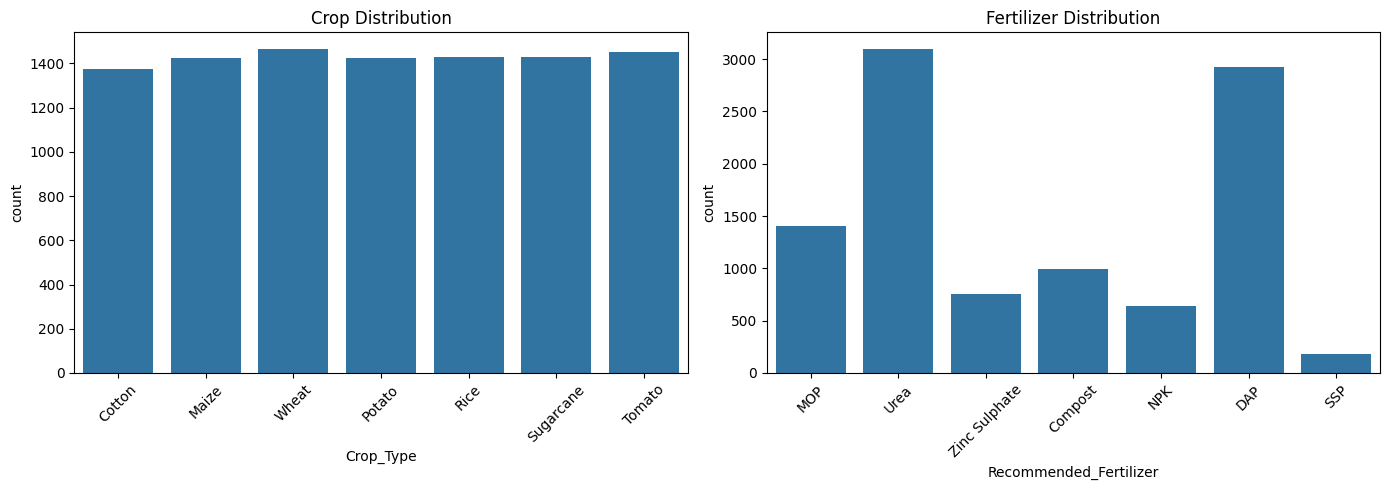

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14,5))

sns.countplot(x="Crop_Type", data=df, ax=ax[0])
ax[0].set_title("Crop Distribution")
ax[0].tick_params(axis='x', rotation=45)

sns.countplot(x="Recommended_Fertilizer", data=df, ax=ax[1])
ax[1].set_title("Fertilizer Distribution")
ax[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

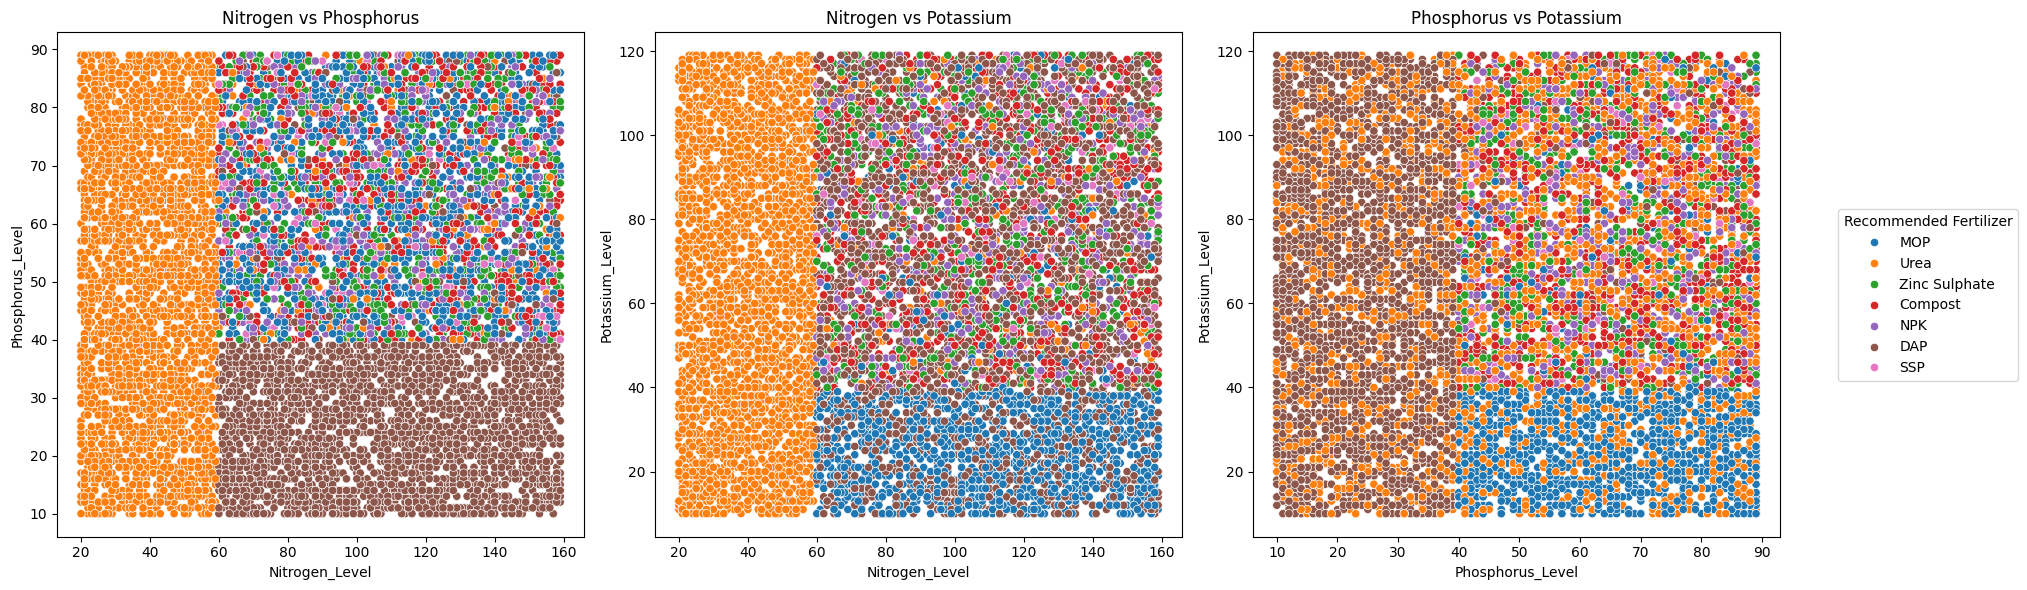

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(18,6))

# Plot 1 (no legend)
sns.scatterplot(
    x="Nitrogen_Level",
    y="Phosphorus_Level",
    hue="Recommended_Fertilizer",
    data=df,
    ax=ax[0],
    legend=False
)
ax[0].set_title("Nitrogen vs Phosphorus")

# Plot 2 (no legend)
sns.scatterplot(
    x="Nitrogen_Level",
    y="Potassium_Level",
    hue="Recommended_Fertilizer",
    data=df,
    ax=ax[1],
    legend=False
)
ax[1].set_title("Nitrogen vs Potassium")

# Plot 3 (generate legend)
scatter = sns.scatterplot(
    x="Phosphorus_Level",
    y="Potassium_Level",
    hue="Recommended_Fertilizer",
    data=df,
    ax=ax[2]
)
ax[2].set_title("Phosphorus vs Potassium")

# Move legend outside
handles, labels = scatter.get_legend_handles_labels()
fig.legend(handles, labels, title="Recommended Fertilizer",
           loc="center left", bbox_to_anchor=(1.02, 0.5))

scatter.legend_.remove()

plt.tight_layout()
plt.show()

## Feature Relevance Analysis

The original dataset contains several environmental and historical parameters.  
However, not all of them are necessary for our decision-support system.

The problem statement requires recommendations based on:

- Soil Moisture
- NPK levels
- Soil pH
- Weather conditions
- Crop type
- Crop growth stage

These are the features farmers can realistically provide as inputs.

Some features represent historical or regional information that farmers cannot easily provide in real-time.

### Removed Features

The following features were removed because they are not directly required for fertilizer decision making.

| Feature | Reason for Removal |
|-------|-------|
Season | Seasonal information already reflected in weather parameters |
Irrigation_Type | Irrigation will be handled by a separate irrigation module |
Previous_Crop | Not required for fertilizer prediction in this system |
Region | Regional bias may reduce model generalization |
Fertilizer_Used_Last_Season | Historical data not available from farmers |
Yield_Last_Season | Outcome variable not needed for fertilizer prediction |
Organic_Carbon | Not part of farmer input parameters |
Electrical_Conductivity | Advanced soil parameter rarely available to farmers |

**Remove Unused Features**

In [ ]:
columns_to_remove = [
    "Season",
    "Irrigation_Type",
    "Previous_Crop",
    "Region",
    "Fertilizer_Used_Last_Season",
    "Yield_Last_Season",
    "Organic_Carbon",
    "Electrical_Conductivity"
]

df = df.drop(columns=columns_to_remove)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Soil_Type               10000 non-null  object 
 1   Soil_pH                 10000 non-null  float64
 2   Soil_Moisture           10000 non-null  float64
 3   Nitrogen_Level          10000 non-null  int64  
 4   Phosphorus_Level        10000 non-null  int64  
 5   Potassium_Level         10000 non-null  int64  
 6   Temperature             10000 non-null  float64
 7   Humidity                10000 non-null  float64
 8   Rainfall                10000 non-null  float64
 9   Crop_Type               10000 non-null  object 
 10  Crop_Growth_Stage       10000 non-null  object 
 11  Recommended_Fertilizer  10000 non-null  object 
dtypes: float64(5), int64(3), object(4)
memory usage: 937.6+ KB


**Encode Categorical Features**

In [ ]:
from sklearn.preprocessing import LabelEncoder

soil_encoder = LabelEncoder()
crop_encoder = LabelEncoder()
stage_encoder = LabelEncoder()
fert_encoder = LabelEncoder()

df["Soil_Type"] = soil_encoder.fit_transform(df["Soil_Type"])
df["Crop_Type"] = crop_encoder.fit_transform(df["Crop_Type"])
df["Crop_Growth_Stage"] = stage_encoder.fit_transform(df["Crop_Growth_Stage"])
df["Recommended_Fertilizer"] = fert_encoder.fit_transform(df["Recommended_Fertilizer"])

**Save Encoders**

In [ ]:
import joblib

joblib.dump(soil_encoder, "/content/drive/MyDrive/RKdemy/soil_encoder.pkl")
joblib.dump(crop_encoder, "/content/drive/MyDrive/RKdemy/crop_encoder.pkl")
joblib.dump(stage_encoder, "/content/drive/MyDrive/RKdemy/stage_encoder.pkl")
joblib.dump(fert_encoder, "/content/drive/MyDrive/RKdemy/fert_encoder.pkl")

['/content/drive/MyDrive/RKdemy/fert_encoder.pkl']

**Compute Dataset Thresholds (Used for Normalization)**

In [ ]:
n_low = df["Nitrogen_Level"].quantile(0.33)
n_high = df["Nitrogen_Level"].quantile(0.66)

p_low = df["Phosphorus_Level"].quantile(0.33)
p_high = df["Phosphorus_Level"].quantile(0.66)

k_low = df["Potassium_Level"].quantile(0.33)
k_high = df["Potassium_Level"].quantile(0.66)

thresholds = {
    "N_low": n_low,
    "N_high": n_high,
    "P_low": p_low,
    "P_high": p_high,
    "K_low": k_low,
    "K_high": k_high
}

joblib.dump(thresholds, "/content/drive/MyDrive/RKdemy/nutrient_thresholds.pkl")

['/content/drive/MyDrive/RKdemy/nutrient_thresholds.pkl']

**Separate Features and Target**

In [ ]:
X = df.drop("Recommended_Fertilizer", axis=1)
y = df["Recommended_Fertilizer"]

**Apply SMOTE to Balance Fertilizers**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

#Convert back to dataframe
df_smote = X_resampled.copy()
df_smote["Recommended_Fertilizer"] = y_resampled

**Plot Before vs After SMOTE**

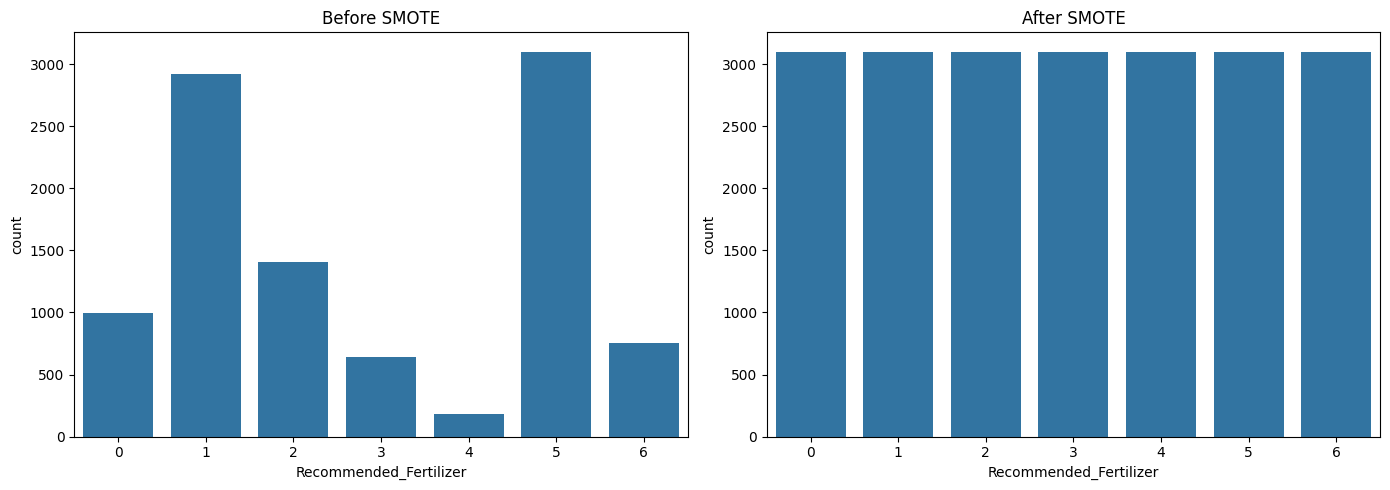

In [ ]:
fig, ax = plt.subplots(1,2, figsize=(14,5))

sns.countplot(x="Recommended_Fertilizer", data=df, ax=ax[0])
ax[0].set_title("Before SMOTE")

sns.countplot(x="Recommended_Fertilizer", data=df_smote, ax=ax[1])
ax[1].set_title("After SMOTE")

plt.tight_layout()
plt.show()

**Train-Test Split (Important)**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_resampled,
    y_resampled,
    test_size=0.2,
    random_state=42
)

print("Training: ",X_train.shape)
print("Testing: ",X_test.shape)

Training:  (17365, 11)
Testing:  (4342, 11)


**Training the Model with Random Forest**

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

**Model Prediction**

In [ ]:
y_pred = rf_model.predict(X_test)

**Evaluation**

In [ ]:
from sklearn.metrics import classification_report, accuracy_score

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.96      0.89      0.92       627
           1       1.00      0.94      0.97       565
           2       1.00      0.90      0.95       647
           3       0.87      0.93      0.90       638
           4       0.82      0.99      0.90       637
           5       1.00      0.94      0.97       621
           6       0.94      0.91      0.93       607

    accuracy                           0.93      4342
   macro avg       0.94      0.93      0.93      4342
weighted avg       0.94      0.93      0.93      4342



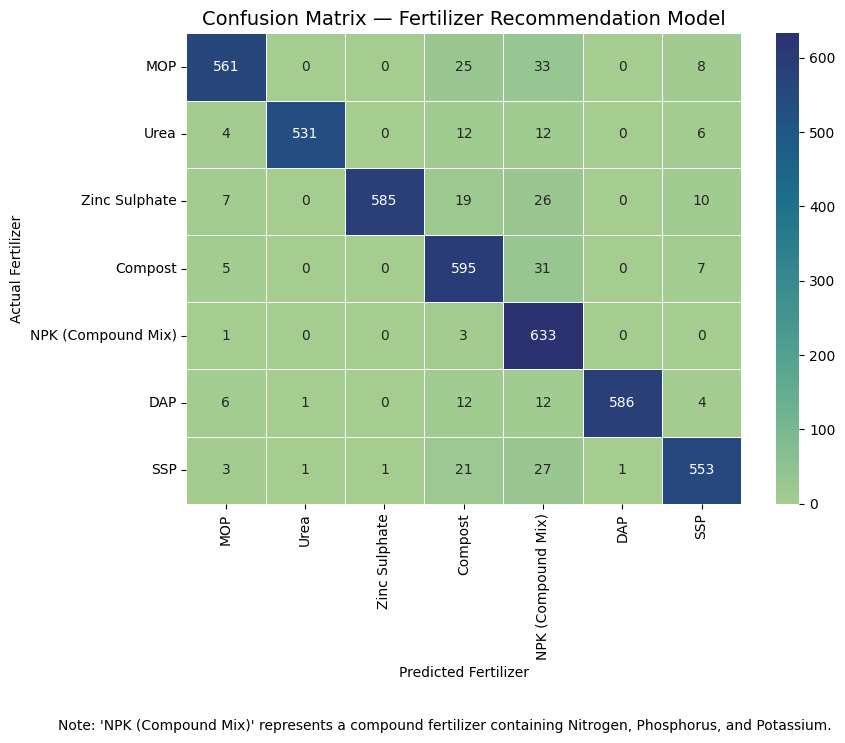

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

labels = [
    "MOP",
    "Urea",
    "Zinc Sulphate",
    "Compost",
    "NPK (Compound Mix)",
    "DAP",
    "SSP"
]

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(9,7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="crest",      # softer color palette
    xticklabels=labels,
    yticklabels=labels,
    linewidths=0.6,
    linecolor="white",
    cbar=True
)

plt.title("Confusion Matrix — Fertilizer Recommendation Model", fontsize=14)
plt.xlabel("Predicted Fertilizer")
plt.ylabel("Actual Fertilizer")

plt.figtext(
    0.5,
    -0.05,
    "Note: 'NPK (Compound Mix)' represents a compound fertilizer containing Nitrogen, Phosphorus, and Potassium.",
    ha="center",
    fontsize=10
)

plt.tight_layout()
plt.show()

**Save Final Model**

In [ ]:
import joblib

joblib.dump(rf_model, "/content/drive/MyDrive/RKdemy/fertilizer_model_final_V2.pkl")

['/content/drive/MyDrive/RKdemy/fertilizer_model_final_V2.pkl']

**Save Feature Order (Important for Prediction)**

In [ ]:
feature_columns = X.columns.tolist()
joblib.dump(feature_columns, "/content/drive/MyDrive/RKdemy/feature_columns.pkl")

['/content/drive/MyDrive/RKdemy/feature_columns.pkl']